In [1]:
!pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\users\\s1f10\\miniconda3\\envs\\ds2026\\lib\\site-packages\\numpy-2.2.6-cp310-cp310-win_amd64.whl'



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

例えば、変圧器のオイル温度は以下の要因で変動する：

負荷（電流・電力）

周囲温度

時間帯（昼夜）

運転状態

物理を知らないと
「なんでこの特徴量が効いてるの？」
が説明しづらい。

2. 特徴量設計の質
例えば、負荷と温度の関係は非線形なので、

対数変換

移動平均

温度差分
などの特徴量が有効になる可能性が高い。

物理を知っていると「なぜその特徴量を作ったか」を説明しやすい。

### もし「物理の知識がないけど不安」という場合は、
### 最低限以下だけ押さえれば十分：

変圧器のオイル温度は負荷と周囲温度で決まる

温度は慣性があるので急には変わらない

異常時は温度が急上昇することがある

## データセットの期間は 2016 年 7 月～2018 年 7 月です。

## データ詳細
選択されたページの説明に基づいて、**ETT-small**データセットに含まれる `h1`, `h2`, `m1`, `m2` の各ファイルの内容および違いについて解説します。

**データセットの構成**
中国の省の2つの異なる地域（ステーション）から収集された2台の変圧器のデータです。

* **1**（h1 / m1）：地域1の変圧器データ
* **2**（h2 / m2）：地域2の変圧器データ

**記録間隔（サンプリング周期）の違い**

* **`m1` / `m2`（分単位データ：15分刻み）**
* 各データポイントが記録された2年分のデータです。
* 15分ごとに1回記録されており、データセットごとの総データ数は **70,080 個**（2年 × 365日 × 24時間 × 4回）です。


* **`h1` / `h2`（時間単位データ：1時間刻み）**
* 開発や実験を迅速化するために作成された、1時間単位のバリアントデータです。



**含まれるデータ項目（全8特徴量）**
すべてのファイル（h1, h2, m1, m2）において、以下の共通の8つの列（ヘッダー）で構成されています。

* **date**：記録された日時
* **HUFL**（High Use Full Load）：高使用・フル負荷
* **HULL**（High Use Low Load）：高効率・低負荷
* **MUFL**（Middle Use Full Load）：中使用・フル負荷
* **MULL**（Middle Use Low Load）：中使用・低負荷
* **LUFL**（Low Use Full Load）：低使用・フル負荷
* **LULL**（Low Use Low Load）：低使用・低負荷
* **OT**（Oil Temperature）：油温（予測目標値）

## 目的　オイル温度を将来予測することで、実際の運用・保全判断にどの程度価値を出せそうか？
## 目標：オイル温度の閾値を超える数時間前に予兆を予測すること

## 可視化
### 負荷変動や外部要因の影響がオイル温度にどのような影響を与えるのか。時系列で見る
#### ・OTとそれ以外の変数を時系列でグラフにして、季節ごとのトレンドはないかをみる。
### なんで二つの工場を出しているのか、比べると何か見えるかも、ビジネス的なアプローチができるかもしれない。

#　変電所や大規模施設等にある高圧〜特別高圧用の変圧器（巨大な冷却油タンクや冷却器を備えた設備）と仮定

# 工場１

In [4]:
csv_in ='./data/ETTh1.csv'
df = pd.read_csv(csv_in,sep=',',header=0)

print(df.shape)
print(df.info())
display(df.head())
display(df.tail())

(17420, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB
None


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
17415,2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904
17416,2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044
17417,2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271
17418,2018-06-26 18:00:00,9.243,3.818,5.472,2.097,3.655,1.432,9.778
17419,2018-06-26 19:00:00,10.114,3.550,6.183,1.564,3.716,1.462,9.567


In [5]:

df['date']= pd.to_datetime(df['date'])

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[ns]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.1 MB
None


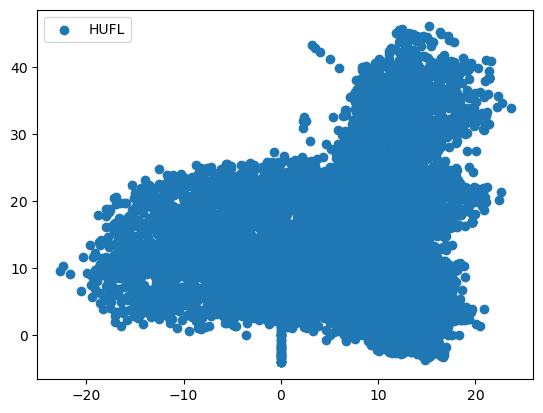

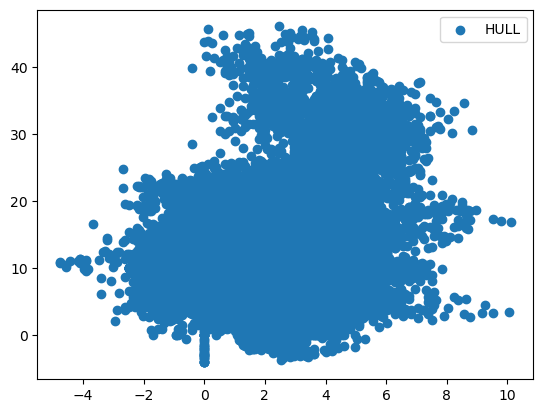

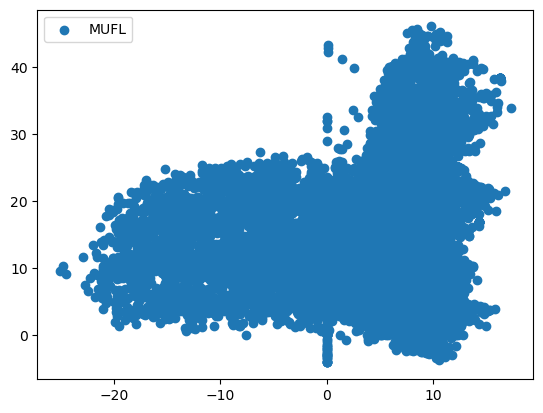

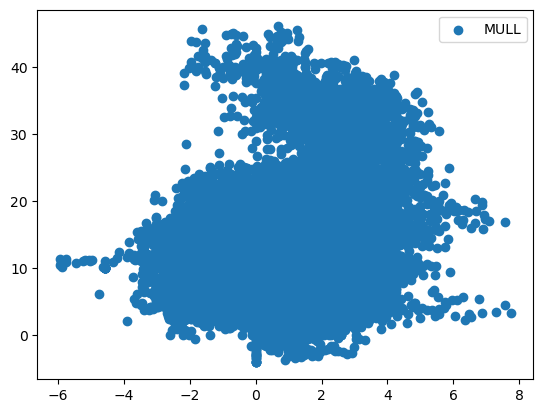

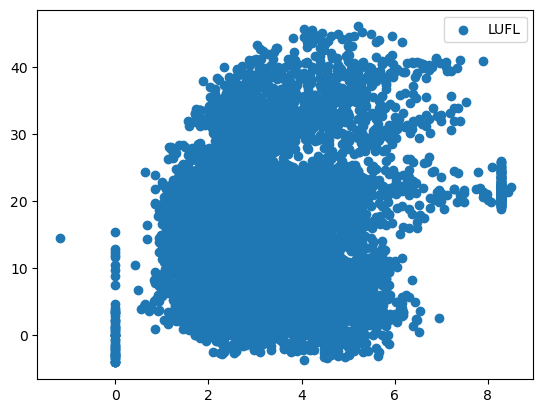

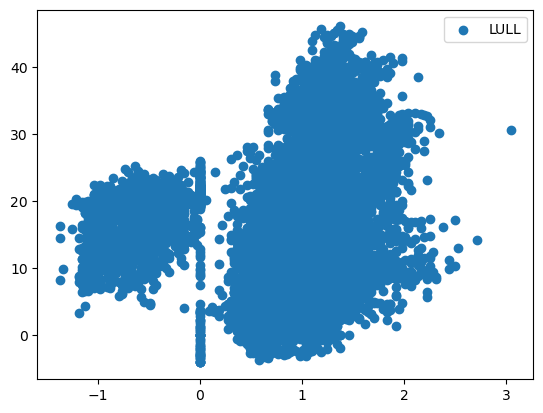

In [7]:
for c in ['HUFL','HULL','MUFL','MULL','LUFL','LULL']:
    plt.scatter(df[c],df['OT'],label=c)
    plt.legend()
    plt.show()

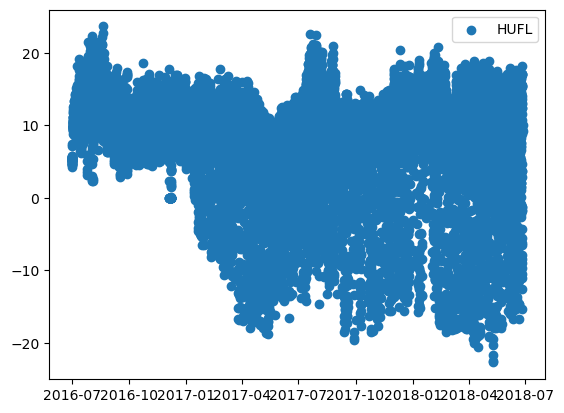

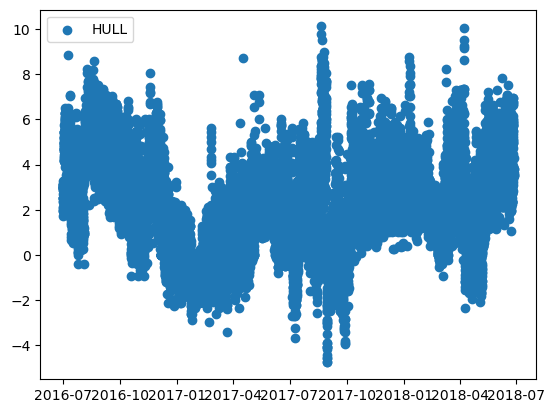

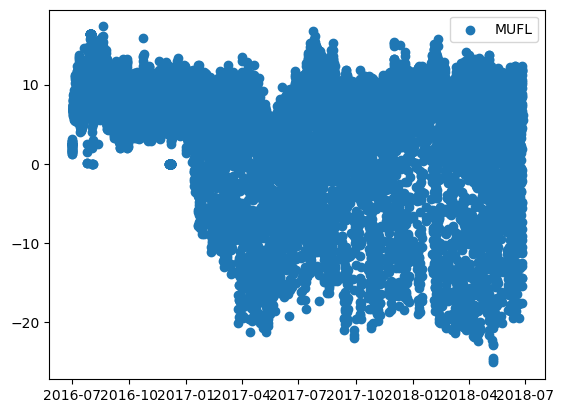

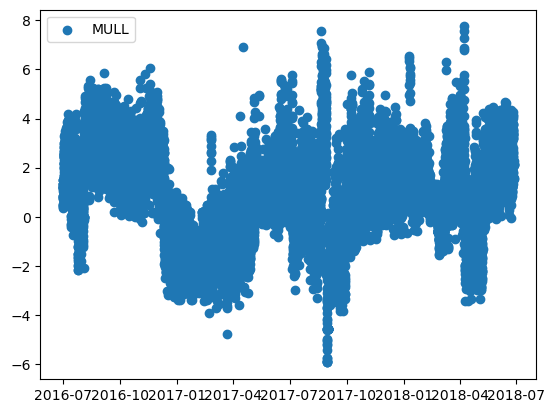

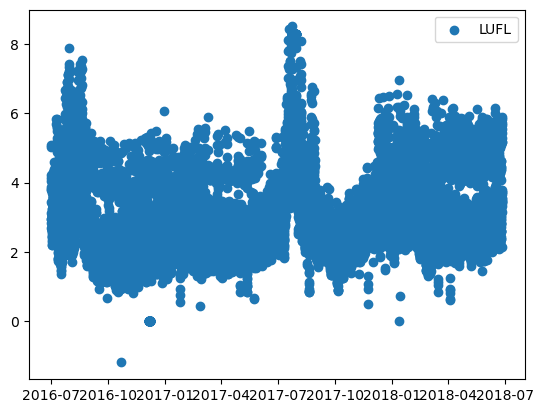

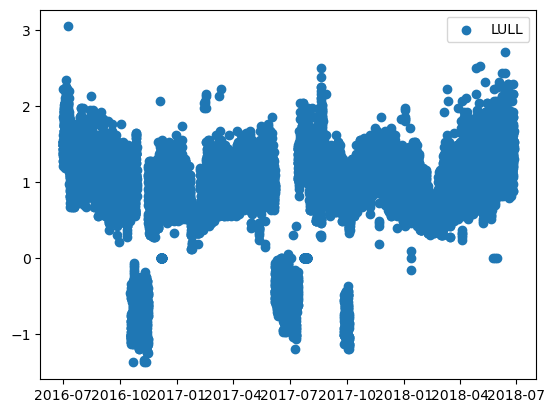

In [8]:
for c in ['HUFL','HULL','MUFL','MULL','LUFL','LULL']:
    plt.scatter(df['date'],df[c],label=c)
    plt.legend()
    plt.show()

In [9]:
# datetime型なら、年（year）を数値で指定するのがベスト
df_2017 = df[df['date'].dt.year == 2017]
display(df_2017.head())
display(df_2017.tail())
print(df.info())

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
4416,2017-01-01 00:00:00,12.927,1.273,8.919,-0.959,4.904,1.432,10.200
4417,2017-01-01 01:00:00,13.798,1.674,9.985,0.036,4.264,1.218,10.060
4418,2017-01-01 02:00:00,13.597,1.407,9.097,-0.142,4.142,1.097,9.919
4419,2017-01-01 03:00:00,13.195,1.942,9.310,-0.497,4.234,1.249,9.215
4420,2017-01-01 04:00:00,14.468,2.076,10.163,-0.142,4.508,1.401,10.130


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
13171,2017-12-31 19:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13172,2017-12-31 20:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13173,2017-12-31 21:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13174,2017-12-31 22:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221
13175,2017-12-31 23:00:00,14.535,3.952,9.808,2.523,4.599,0.883,4.221


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[ns]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 1.1 MB
None


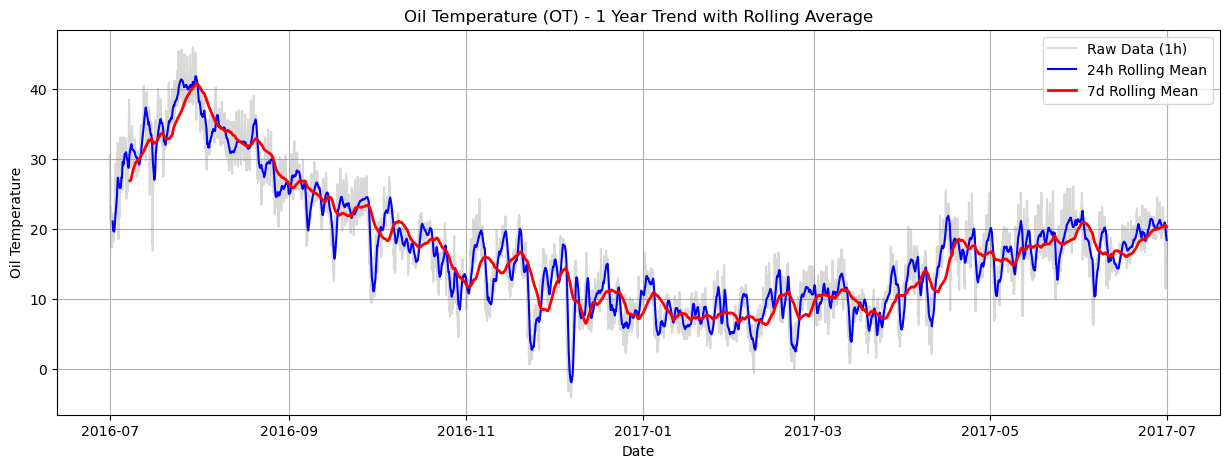

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# データの読み込み（例: ETTh1）
df["date"] = pd.to_datetime(df["date"])

# 1年分にフィルタリング
df_1year = df[(df["date"] >= "2016-07-01") & (df["date"] < "2017-07-01")].copy()

# 24時間移動平均と7日（168時間）移動平均の計算
df_1year["OT_24h_mean"] = df_1year["OT"].rolling(window=24).mean()
df_1year["OT_7d_mean"] = df_1year["OT"].rolling(window=168).mean()

# プロット
plt.figure(figsize=(15, 5))
plt.plot(
    df_1year["date"],
    df_1year["OT"],
    alpha=0.3,
    color="gray",
    label="Raw Data (1h)",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_24h_mean"],
    color="blue",
    linewidth=1.5,
    label="24h Rolling Mean",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_7d_mean"],
    color="red",
    linewidth=2,
    label="7d Rolling Mean",
)

plt.title("Oil Temperature (OT) - 1 Year Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.legend()
plt.grid(True)
plt.show()

### 中国には四季があるため、それをもとに分析する

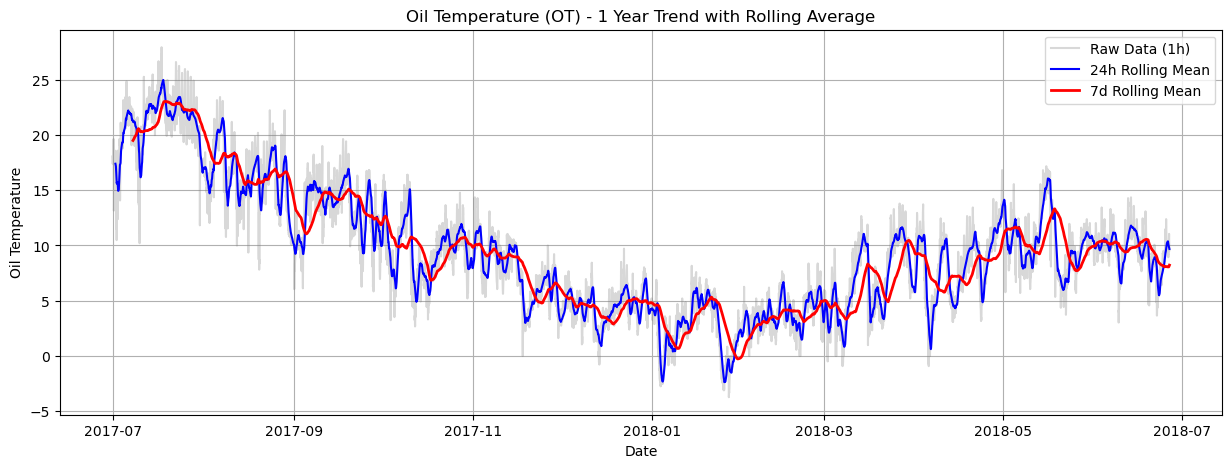

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# データの読み込み（例: ETTh1）
df["date"] = pd.to_datetime(df["date"])

# 1年分にフィルタリング
df_1year = df[(df["date"] >= "2017-07-01") & (df["date"] < "2018-07-01")].copy()

# 24時間移動平均と7日（168時間）移動平均の計算
df_1year["OT_24h_mean"] = df_1year["OT"].rolling(window=24).mean()
df_1year["OT_7d_mean"] = df_1year["OT"].rolling(window=168).mean()

# プロット
plt.figure(figsize=(15, 5))
plt.plot(
    df_1year["date"],
    df_1year["OT"],
    alpha=0.3,
    color="gray",
    label="Raw Data (1h)",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_24h_mean"],
    color="blue",
    linewidth=1.5,
    label="24h Rolling Mean",
)
plt.plot(
    df_1year["date"],
    df_1year["OT_7d_mean"],
    color="red",
    linewidth=2,
    label="7d Rolling Mean",
)

plt.title("Oil Temperature (OT) - 1 Year Trend with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.legend()
plt.grid(True)
plt.show()

###  夏は外気温が高くなるため、オイルも自然と熱くなる。8月ごろに40℃のオイル温度になっている
#####  オイル温度を決める要因：負荷（電流・電力）、周囲温度、時間帯（昼夜）、運転状態

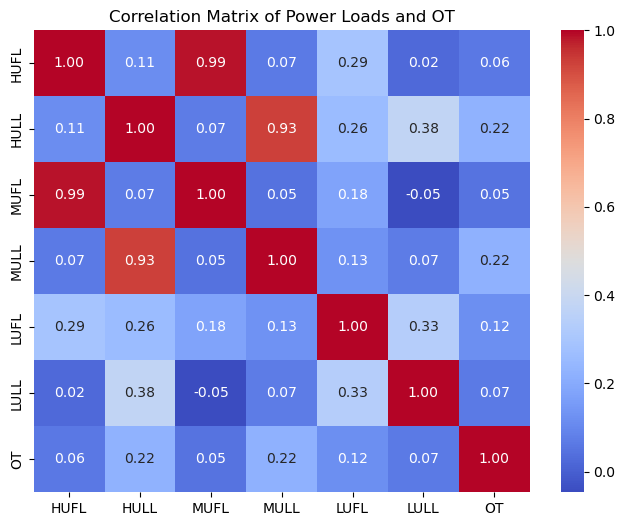

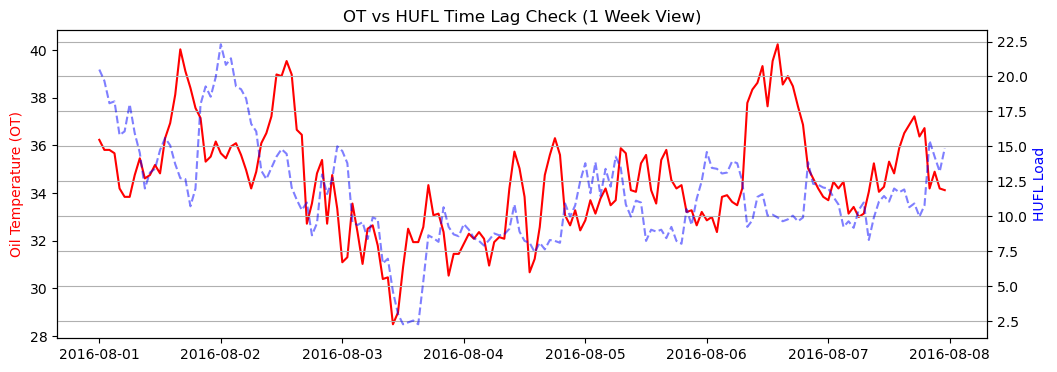

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 相関ヒートマップの作成
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix of Power Loads and OT")
plt.show()

# 2. OTと代表的負荷（HUFL）のラグ関係の可視化（1週間分）
df_sample = df[(df["date"] >= "2016-08-01") & (df["date"] < "2016-08-08")]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_sample["date"], df_sample["OT"], color="red", label="OT (Target)")
ax1.set_ylabel("Oil Temperature (OT)", color="red")

ax2 = ax1.twinx()
ax2.plot(
    df_sample["date"],
    df_sample["HUFL"],
    color="blue",
    alpha=0.5,
    linestyle="--",
    label="HUFL",
)
ax2.set_ylabel("HUFL Load", color="blue")

plt.title("OT vs HUFL Time Lag Check (1 Week View)")
plt.grid(True)
plt.show()

## OT と各説明変数の1対1比較（twinx で2軸プロット）
負荷系6変数（HUFL/HULL/MUFL/MULL/LUFL/LULL）を1変数ずつ OT と重ねて、
どの変数がどのタイミングで OT に効いているか（位相のずれ＝タイムラグ）を目視で確認する。


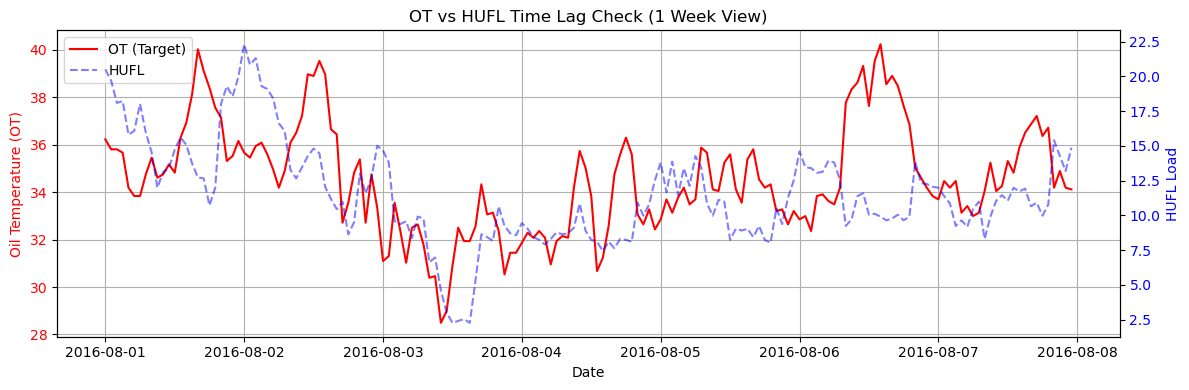

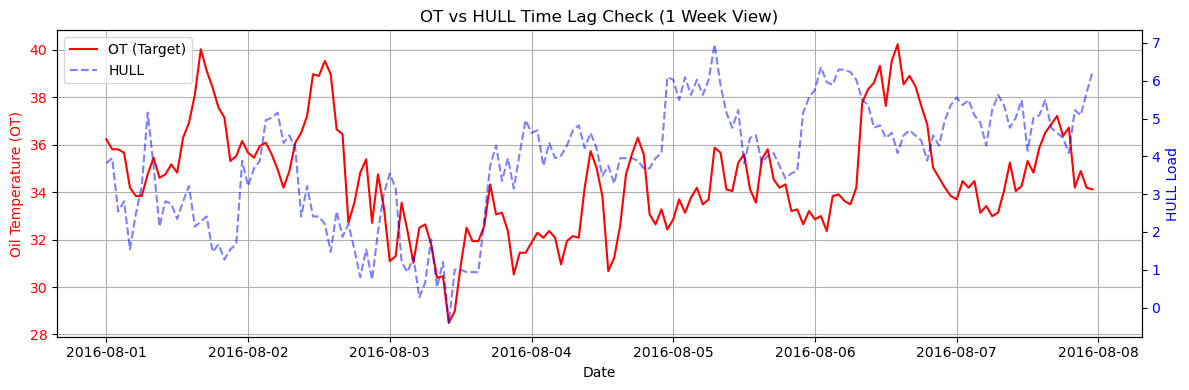

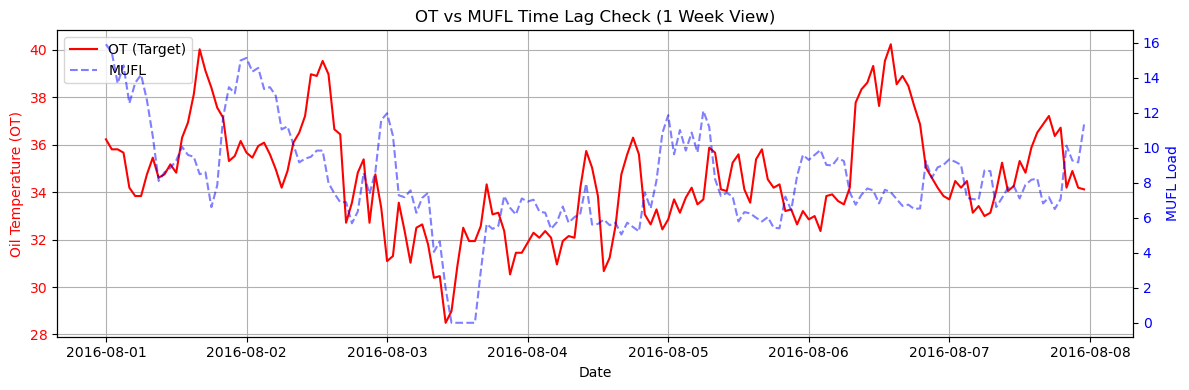

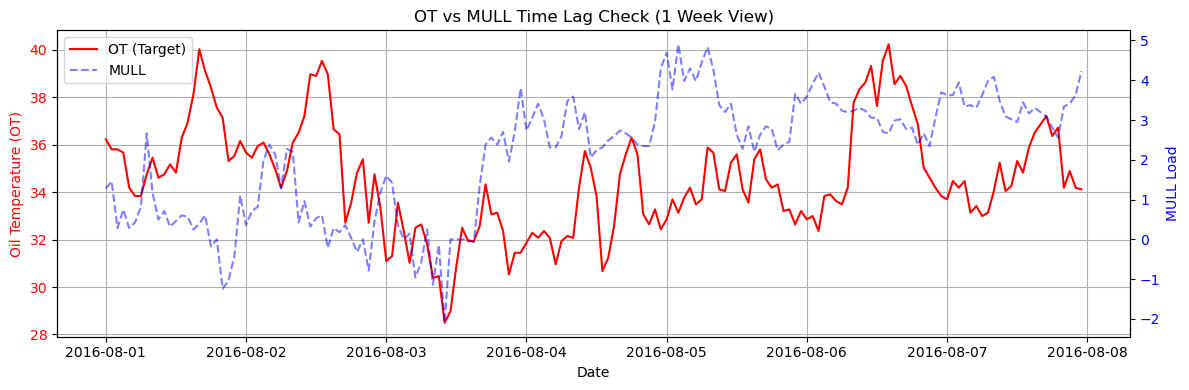

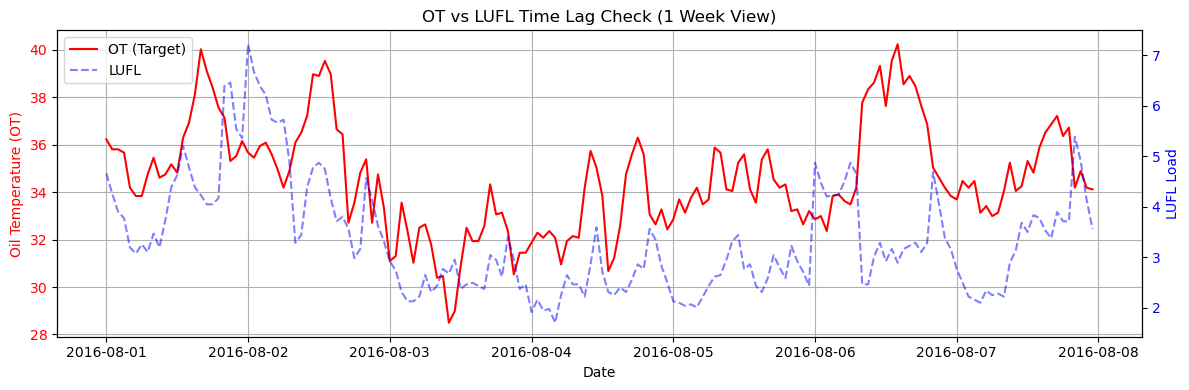

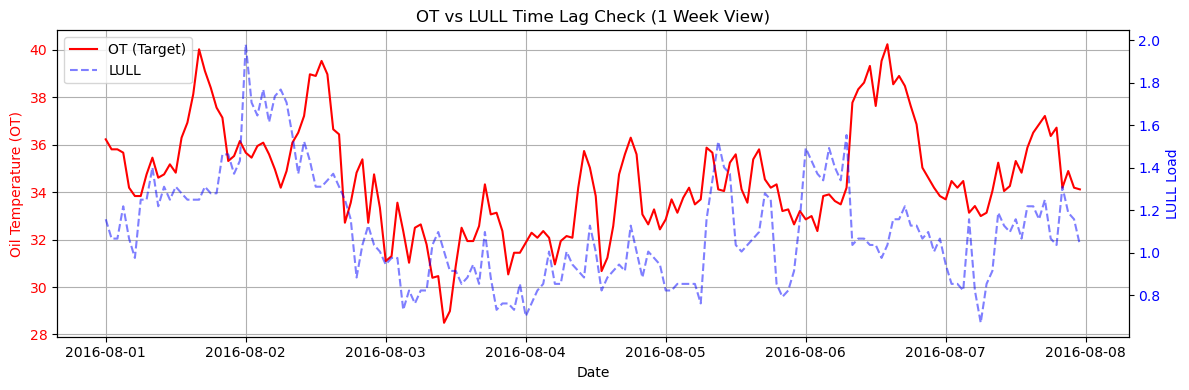

In [13]:
import matplotlib.pyplot as plt

FEATURES = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]

# 1週間分を切り出して、1変数ずつ OT と比較する
df_sample = df[(df["date"] >= "2016-08-01") & (df["date"] < "2016-08-08")]

for c in FEATURES:
    fig, ax1 = plt.subplots(figsize=(12, 4))

    ax1.plot(df_sample["date"], df_sample["OT"], color="red", label="OT (Target)")
    ax1.set_ylabel("Oil Temperature (OT)", color="red")
    ax1.tick_params(axis="y", labelcolor="red")
    ax1.set_xlabel("Date")

    ax2 = ax1.twinx()
    ax2.plot(
        df_sample["date"],
        df_sample[c],
        color="blue",
        alpha=0.5,
        linestyle="--",
        label=c,
    )
    ax2.set_ylabel(f"{c} Load", color="blue")
    ax2.tick_params(axis="y", labelcolor="blue")

    # 2軸ぶんの凡例をまとめて表示
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.title(f"OT vs {c} Time Lag Check (1 Week View)")
    ax1.grid(True)
    plt.tight_layout()
    plt.show()


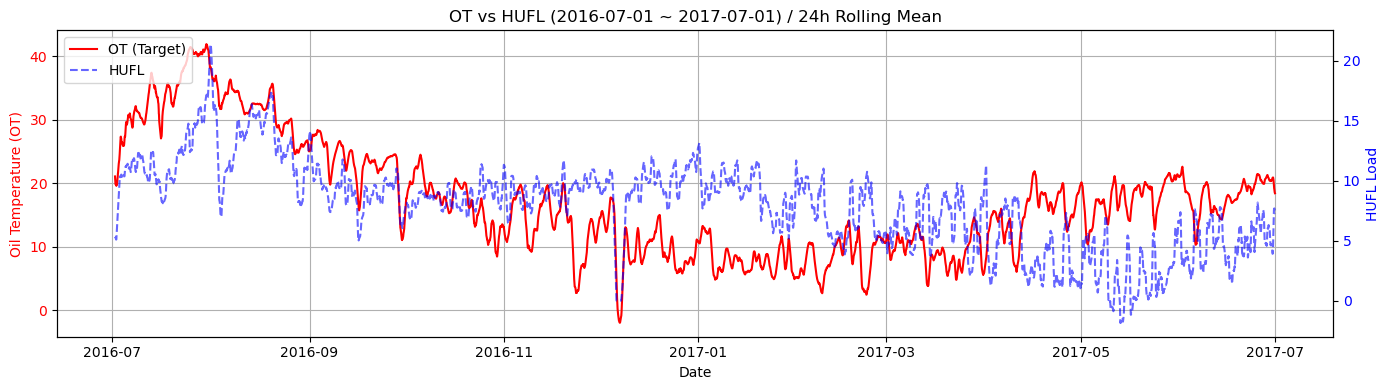

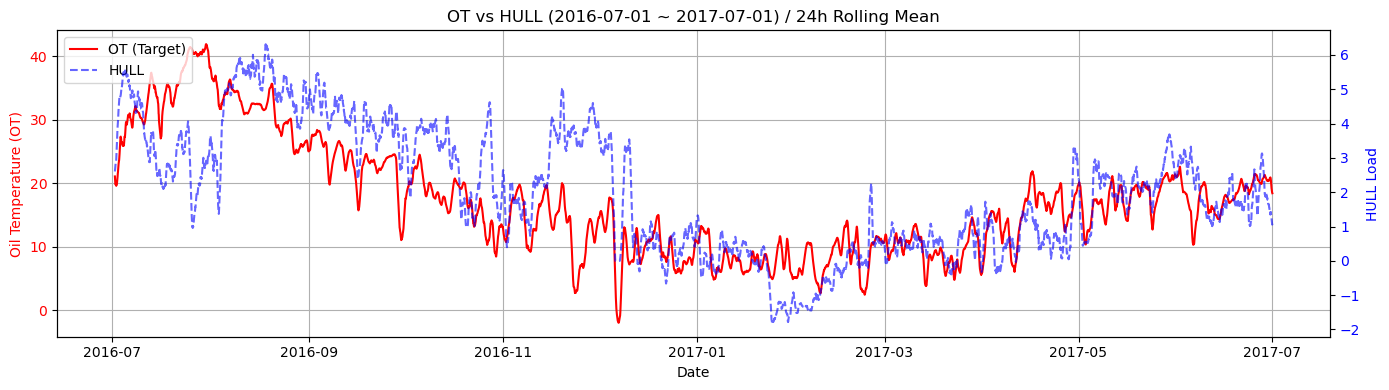

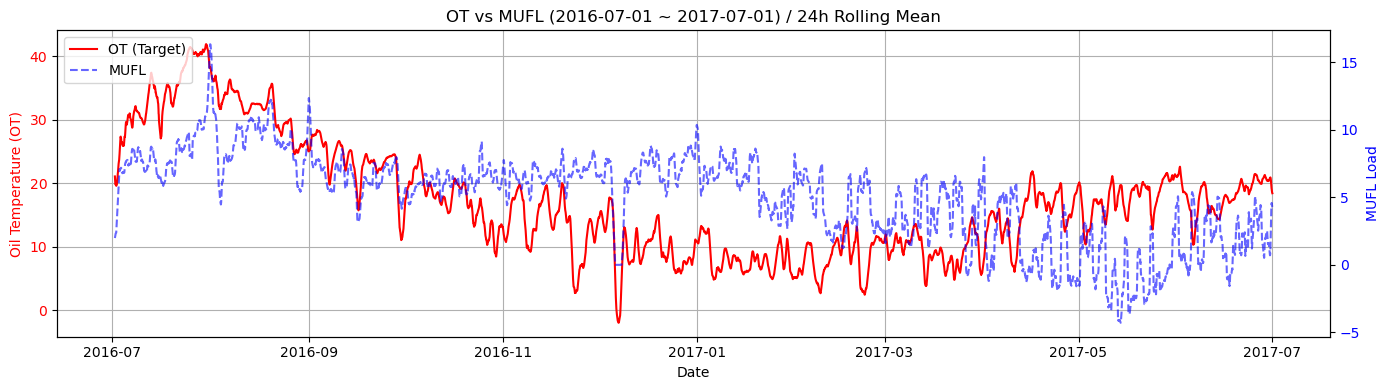

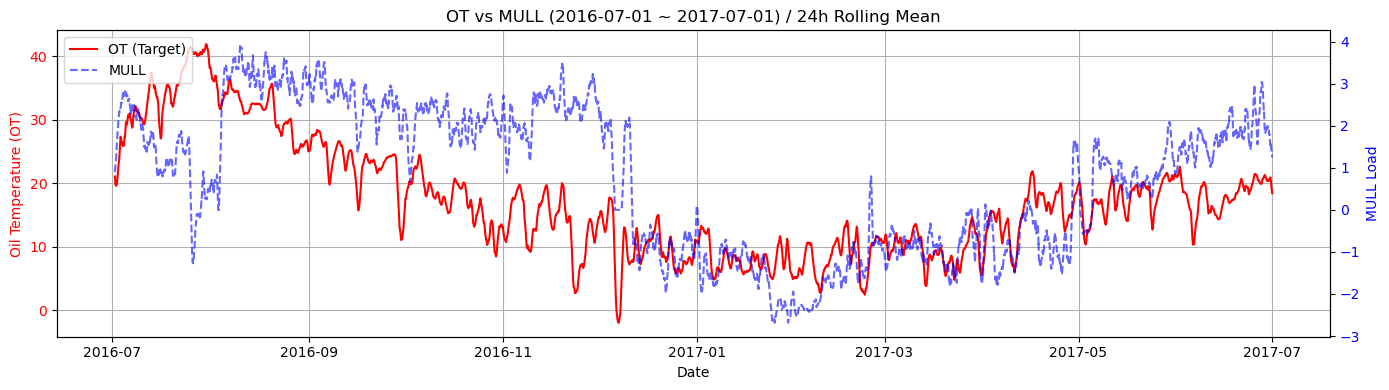

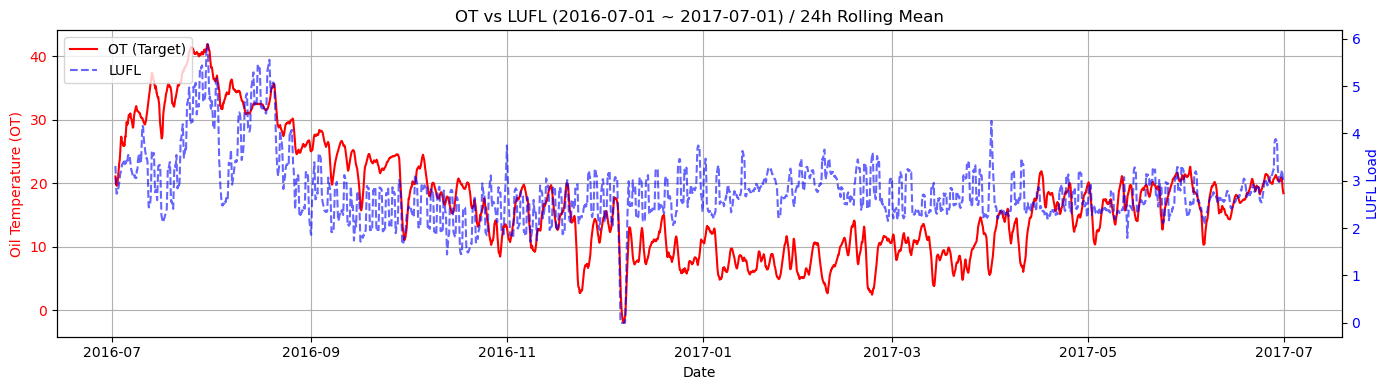

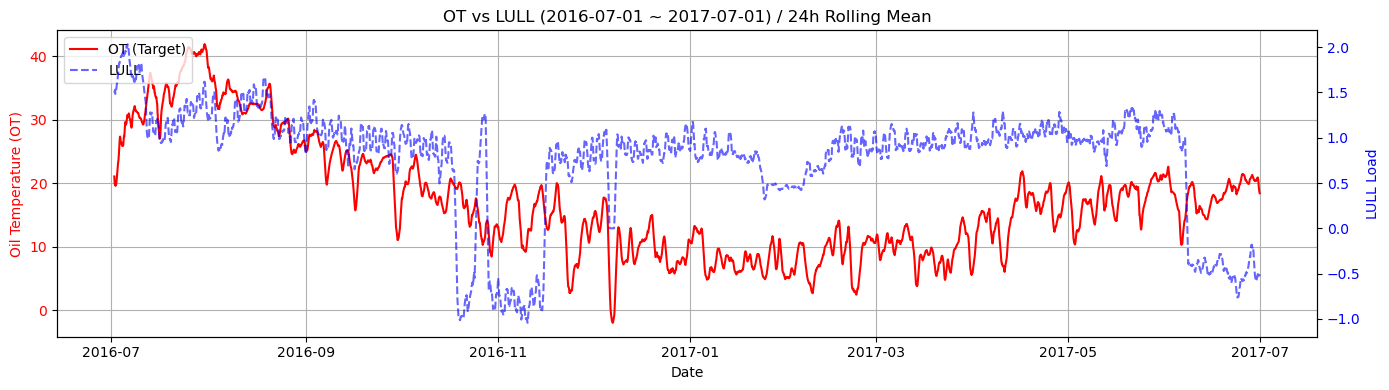

In [14]:
def plot_ot_vs(col, start, end, smooth=None, ax_title=None):
    """OT と説明変数 col を2軸で重ねてプロットする。

    col    : 比較したい列名（例: "HUFL"）
    start  : 開始日（例: "2016-08-01"）
    end    : 終了日（例: "2016-08-08"）
    smooth : 移動平均の窓（時間数）。None なら生データのまま
    """
    d = df[(df["date"] >= start) & (df["date"] < end)].copy()

    y_ot = d["OT"]
    y_c = d[col]
    suffix = ""
    if smooth:
        y_ot = y_ot.rolling(window=smooth).mean()
        y_c = y_c.rolling(window=smooth).mean()
        suffix = f" / {smooth}h Rolling Mean"

    fig, ax1 = plt.subplots(figsize=(14, 4))

    ax1.plot(d["date"], y_ot, color="red", label="OT (Target)")
    ax1.set_ylabel("Oil Temperature (OT)", color="red")
    ax1.tick_params(axis="y", labelcolor="red")
    ax1.set_xlabel("Date")

    ax2 = ax1.twinx()
    ax2.plot(d["date"], y_c, color="blue", alpha=0.6, linestyle="--", label=col)
    ax2.set_ylabel(f"{col} Load", color="blue")
    ax2.tick_params(axis="y", labelcolor="blue")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.title(ax_title or f"OT vs {col} ({start} ~ {end}){suffix}")
    ax1.grid(True)
    plt.tight_layout()
    plt.show()


# 1年スケール（24h移動平均で平滑化）で季節トレンドを見る
for c in FEATURES:
    plot_ot_vs(c, "2016-07-01", "2017-07-01", smooth=24)


In [16]:
# どのラグで相関が最大になるかを数値でも確認する（正のラグ = 説明変数が OT に先行）
MAX_LAG = 48  # 時間

rows = []
for c in FEATURES:
    corrs = {lag: df["OT"].corr(df[c].shift(lag)) for lag in range(0, MAX_LAG + 1)}
    best_lag = max(corrs, key=lambda k: abs(corrs[k]))
    rows.append(
        {
            "feature": c,
            "corr_lag0": corrs[0],
            "best_lag_h": best_lag,
            "corr_at_best_lag": corrs[best_lag],
        }
    )

lag_summary = pd.DataFrame(rows).sort_values("corr_at_best_lag", key=abs, ascending=False)
display(lag_summary)


,feature,corr_lag0,best_lag_h,corr_at_best_lag
1,HULL,0.224354,10,0.263186
3,MULL,0.220004,10,0.254112
0,HUFL,0.059916,15,0.146722
2,MUFL,0.050854,15,0.141126
4,LUFL,0.118836,7,0.133111
5,LULL,0.067455,6,0.078568


## 検証1：土日・祝日で電力需要は下がるのか

### 仮説
変電所につながる需要家の構成によって、休日の負荷の落ち方は変わるはずである。

- **仮説A（産業需要が主体）**: 工場が休むため土日に負荷が下がる。とくに中国最大の連休である**春節（7連休）**では大幅に落ちるはず。
- **仮説B（生活需要が主体）**: 在宅時間が増えるため土日でも負荷は下がらず、むしろ上がる可能性がある。祝日でも大きくは変わらない。

どちらが成り立つかで、この変電所が「工業向け」か「生活向け」かを推定でき、
保全の優先度や需要予測の設計方針が変わる。

### 検証方法
各時点を **平日 / 土日 / 祝日 / 振替出勤日** に分類し、有効電力(HUFL)とOTの平均を比較する。

中国には**振替出勤（调休）**という制度があり、連休を作るために土日が出勤日になる。
単純な曜日判定では「土日なのに負荷が高い」と誤解するため、これを区別する。

### 注意（データ品質）
毎月31日は全項目が24時間まったく同じ値で埋まっている（データ期間中14日すべて）。
実測ではなく合成値とみられるため、集計から除外する。


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df["date"] = pd.to_datetime(df["date"])

# --- 中国の法定節假日（データ期間 2016-07 〜 2018-06）---
CN_HOLIDAYS = [
    ("2016-09-15", "2016-09-17", "Mid-Autumn"),
    ("2016-10-01", "2016-10-07", "National Day"),
    ("2017-01-01", "2017-01-02", "New Year"),
    ("2017-01-27", "2017-02-02", "Spring Fes."),
    ("2017-04-02", "2017-04-04", "Qingming"),
    ("2017-04-29", "2017-05-01", "Labour Day"),
    ("2017-05-28", "2017-05-30", "Dragon Boat"),
    ("2017-10-01", "2017-10-08", "Nat'l+Mid-Aut"),
    ("2018-01-01", "2018-01-01", "New Year"),
    ("2018-02-15", "2018-02-21", "Spring Fes."),
    ("2018-04-05", "2018-04-07", "Qingming"),
    ("2018-04-29", "2018-05-01", "Labour Day"),
    ("2018-06-16", "2018-06-18", "Dragon Boat"),
]
# 振替出勤日(调休): 土日だが出勤日
MAKEUP = ["2016-09-18", "2016-10-08", "2016-10-09", "2017-01-22", "2017-02-04",
          "2017-04-01", "2017-05-27", "2017-09-30", "2018-02-11", "2018-02-24",
          "2018-04-08", "2018-04-28"]

# 毎月31日は全項目が定数の合成データ → 除外
d = df[df["date"].dt.day != 31].copy()


def day_type(ts):
    day = ts.normalize()
    for s, e, _ in CN_HOLIDAYS:
        if pd.Timestamp(s) <= day <= pd.Timestamp(e):
            return "Holiday"
    if day.strftime("%Y-%m-%d") in MAKEUP:
        return "Makeup"
    return "Weekend" if day.dayofweek >= 5 else "Weekday"


d["day_type"] = d["date"].map(day_type)

order = ["Weekday", "Weekend", "Holiday", "Makeup"]
g = d.groupby("day_type")[["HUFL", "OT"]].agg(["mean", "count"]).reindex(order)
print("■ 区分別の平均")
print(g.round(2).to_string())

base = g[("HUFL", "mean")]["Weekday"]
print("\n■ 平日を1としたときの有効電力の比")
for t in order:
    if t in g.index and not np.isnan(g[("HUFL", "mean")][t]):
        print("   {:8s} {:.3f}".format(t, g[("HUFL", "mean")][t] / base))

# --- 祝日ごとに、前後2週間の平日と比べる ---
rows = []
for s, e, nm in CN_HOLIDAYS:
    s_ts, e_ts = pd.Timestamp(s), pd.Timestamp(e) + pd.Timedelta(days=1)
    hol = d[(d["date"] >= s_ts) & (d["date"] < e_ts)]
    near = d[(d["date"] >= s_ts - pd.Timedelta(days=14)) &
             (d["date"] < e_ts + pd.Timedelta(days=14)) & (d["day_type"] == "Weekday")]
    if len(hol) and len(near):
        rows.append({"holiday": "{}\n{}".format(nm, s[:7]),
                     "ratio": hol["HUFL"].mean() / near["HUFL"].mean(),
                     "hol_mean": hol["HUFL"].mean(), "base": near["HUFL"].mean()})
hol_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
vals = [g[("HUFL", "mean")][t] for t in order]
bars = ax.bar(order, vals, color=["#4c72b0", "#dd8452", "#c44e52", "#55a868"])
for b, v in zip(bars, vals):
    if not np.isnan(v):
        ax.text(b.get_x() + b.get_width() / 2, v, "{:.2f}".format(v),
                ha="center", va="bottom", fontsize=10)
ax.axhline(base, color="black", linestyle="--", linewidth=1,
           label="Weekday level ({:.2f})".format(base))
ax.set_ylabel("Mean Active Power (HUFL)")
ax.set_title("Mean load by day type")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)

ax = axes[1]
colors = ["#c44e52" if r < 0.9 else "#55a868" for r in hol_df["ratio"]]
ax.bar(hol_df["holiday"], hol_df["ratio"], color=colors)
ax.axhline(1.0, color="black", linewidth=1.2, label="same as weekdays")
ax.axhline(0.9, color="gray", linestyle=":", linewidth=1, label="-10%")
ax.set_ylabel("Holiday load / nearby weekday load")
ax.set_title("Load drop for each public holiday")
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n■ 祝日ごとの平日比")
print(hol_df.assign(holiday=hol_df["holiday"].str.replace(chr(10), " "))[["holiday", "hol_mean", "base", "ratio"]].round(3).to_string(index=False))

we = g[("HUFL", "mean")]["Weekend"] / base
print("\n■ 判定")
print("   土日/平日 = {:.3f}  →  {}".format(
    we, "土日に低下（産業需要の特徴）" if we < 0.9 else "土日でも低下しない（仮説B寄り）"))
cny = hol_df[hol_df["holiday"].str.startswith("Spring Fes.")]["ratio"]
if len(cny):
    print("   春節/平日 = {:.3f}  →  {}".format(
        cny.mean(),
        "春節に大きく低下（工場停止型）" if cny.mean() < 0.8 else "春節でもほぼ落ちない（連続操業型・生活需要型）"))


## 検証2：昼に電力を多く流し、夜に減らすのか

### 仮説
一般的な感覚では「昼間は活動が活発で電力需要が多く、夜間は減る」はずである。

- **仮説C（常識どおり）**: 昼（9–17時）の有効電力 > 夜（21–5時）

ただし、これが崩れる要因も考えられる。

- **太陽光発電の連系**: 変電所が計測するのは「正味の需要」なので、日射のある昼間は見かけの需要が下がる。大量に導入されていれば**マイナス（逆潮流）**にもなりうる
- **夜間料金を使う需要家**: 蓄熱式暖房や夜間操業が主体なら、夜のほうが高くなる
- **連続操業の工場**: 24時間ほぼ一定で、昼夜差がほとんど出ない

### 検証方法
季節ごとに時刻別の平均プロファイルを描き、昼(9–17時)と夜(21–5時)の平均を比較する。

**単日で判断してはいけない。**たまたま典型的でない日を選ぶと逆の結論になりうるため、季節平均で判定する。


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df["date"] = pd.to_datetime(df["date"])

d = df[df["date"].dt.day != 31].copy()   # 31日は合成データのため除外
d["hour"] = d["date"].dt.hour
d["month"] = d["date"].dt.month

SEASONS = {"Spring (3-5)": [3, 4, 5], "Summer (6-8)": [6, 7, 8],
           "Autumn (9-11)": [9, 10, 11], "Winter (12-2)": [12, 1, 2]}
COLORS = {"Spring (3-5)": "#55a868", "Summer (6-8)": "#c44e52",
          "Autumn (9-11)": "#dd8452", "Winter (12-2)": "#4c72b0"}

DAY_H = list(range(9, 18))        # 昼 9-17時
NIGHT_H = list(range(21, 24)) + list(range(0, 6))   # 夜 21-5時

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (1) 時刻別の有効電力プロファイル ---
ax = axes[0]
for name, months in SEASONS.items():
    prof = d[d["month"].isin(months)].groupby("hour")["HUFL"].mean()
    ax.plot(prof.index, prof.values, marker="o", markersize=3,
            color=COLORS[name], label=name)
ax.axvspan(9, 17, color="gold", alpha=0.15, label="daytime 9-17h")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean Active Power (HUFL)")
ax.set_title("Hourly profile of active power by season")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (2) 時刻別のOTプロファイル ---
ax = axes[1]
for name, months in SEASONS.items():
    prof = d[d["month"].isin(months)].groupby("hour")["OT"].mean()
    ax.plot(prof.index, prof.values, marker="o", markersize=3,
            color=COLORS[name], label=name)
ax.axvspan(9, 17, color="gold", alpha=0.15)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean Oil Temperature [degC]")
ax.set_title("Hourly profile of OT by season")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- (3) 昼 vs 夜 の比較 ---
ax = axes[2]
names = list(SEASONS)
day_v, night_v = [], []
for name in names:
    s = d[d["month"].isin(SEASONS[name])]
    day_v.append(s[s["hour"].isin(DAY_H)]["HUFL"].mean())
    night_v.append(s[s["hour"].isin(NIGHT_H)]["HUFL"].mean())
x = np.arange(len(names))
ax.bar(x - 0.2, day_v, 0.4, label="Daytime 9-17h", color="gold", edgecolor="black")
ax.bar(x + 0.2, night_v, 0.4, label="Night 21-5h", color="navy", alpha=0.75)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([n.split()[0] for n in names])
ax.set_ylabel("Mean Active Power (HUFL)")
ax.set_title("Daytime vs Night active power")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("■ 昼(9-17時) と 夜(21-5時) の平均有効電力")
print("  {:14s} {:>9s} {:>9s} {:>8s}   判定".format("季節", "昼", "夜", "昼/夜"))
inverted = 0
for name, dv, nv in zip(names, day_v, night_v):
    ratio = dv / nv if nv else np.nan
    ok = dv > nv
    inverted += (not ok)
    print("  {:14s} {:9.2f} {:9.2f} {:8.2f}   {}".format(
        name, dv, nv, ratio, "昼>夜（仮説C成立）" if ok else "夜>昼（逆転）"))

print("\n■ 判定")
if inverted == 0:
    print("   全季節で昼>夜。一般常識どおりの需要パターン。")
elif inverted == len(names):
    print("   全季節で夜>昼。一般常識は成立しない。")
    print("   → 太陽光の逆潮流、夜間電力の利用などを疑うべき。")
else:
    print("   季節によって逆転する（{}/{} 季節で夜>昼）。".format(inverted, len(names)))

# 逆潮流（有効電力が負）の発生状況
neg = d[d["HUFL"] < 0]
print("\n■ 逆潮流（HUFL < 0）の発生: 全体の {:.1f}%".format(len(neg) / len(d) * 100))
if len(neg):
    by_h = (d.assign(neg=d["HUFL"] < 0).groupby("hour")["neg"].mean() * 100)
    print("   時刻別の発生率(%): 正午={:.0f}%  深夜0時={:.0f}%".format(by_h.get(12, 0), by_h.get(0, 0)))
    print("   開始時期:", neg["date"].min())
